# Rete neurale 2 → 3 → 1 per la previsione del prezzo delle case

In questo notebook costruiamo **da zero**, riga per riga, una rete neurale artificiale.

L'obiettivo è **imparare a stimare il prezzo di una casa** conoscendo:
- la **superficie** in metri quadrati;
- il **numero di stanze**.

### Struttura della rete

```
Input (2 valori)  →  Layer nascosto (3 neuroni)  →  Output (1 valore)
```

Ogni "neurone" è una piccola unità di calcolo che:
1. riceve dei numeri in ingresso;
2. li moltiplica per dei **pesi** (parametri che la rete impara);
3. somma un **bias** (un valore di scostamento);
4. applica una **funzione di attivazione** (qui usiamo la ReLU).

### Cos'è la backpropagation?

Dopo ogni previsione, la rete misura quanto ha sbagliato (**errore**).
La **backpropagation** è l'algoritmo che calcola, per ogni peso,
di quanto e in quale direzione modificarlo per sbagliare di meno la prossima volta.

In questo notebook lo facciamo in modo **esplicito**,
con un ciclo `for` su ogni campione, così è più facile vedere cosa succede matematicamente.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import random


In [13]:
## ─────────────────────────────────────────────────────────
# RIPRODUCIBILITÀ
# ─────────────────────────────────────────────────────────
# Fissare un "seed" (seme) serve a rendere i risultati
# identici ogni volta che eseguiamo il codice.
# Senza questo, i pesi vengono inizializzati in modo
# diverso a ogni esecuzione e i risultati cambiano.

seed = 11
random.seed(seed)       # Seed per la libreria random di Python
np.random.seed(seed)    # Seed per numpy (usa un generatore separato)

2. Il dataset: prezzi delle case

Creiamo un piccolo dataset "giocattolo" con 8 case.

Ogni riga di X descrive una casa:

    colonna 0 → superficie in m²;
    colonna 1 → numero di stanze.

Il vettore y contiene il prezzo reale di ogni casa (in migliaia di €). Questi sono i valori che la rete deve imparare a prevedere.


In [14]:
X = np.array([
    [40,  2],
    [55,  2],
    [70,  3],
    [85,  3],
    [100, 4],
    [120, 4],
    [140, 5],
    [160, 5],
], dtype=float)

y = np.array([95, 120, 150, 180, 215, 250, 295, 335], dtype=float)

print("X shape:", X.shape)   # (8, 2)
print("y shape:", y.shape)   # (8,)


X shape: (8, 2)
y shape: (8,)


## 3. Normalizzazione min-max

Le due feature hanno scale molto diverse:
la superficie va da 40 a 160, il numero di stanze da 2 a 5.

Se le lasciassimo così, la rete faticherebbe ad allenarsi perché
i gradienti avrebbero grandezze molto diverse.

**Min-max scaling**: trasforma ogni valore nell'intervallo [0, 1]:

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

### Perché trasponiamo?


Trasponendo `X_norm` (che ha forma `(8, 2)`),
otteniamo `X_norm_colonne` di forma `(2, 8)`:
- 2 righe → le 2 feature (superficie, stanze);
- 8 colonne → le 8 case.

Così possiamo scrivere direttamente `W1 @ X_norm_colonne`.

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Dopo la normalizzazione trasponiamo in modo che ogni **colonna** rappresenti
un campione. Gli input normalizzati corrispondono a $z^{(0)}$ nelle slide:

$$Z^{(0)} = \begin{bmatrix} z_1^{(0)} \\ z_2^{(0)} \end{bmatrix}
\in \mathbb{R}^{2 \times n}$$


In [3]:
X_min = X.min(axis=0)
X_max = X.max(axis=0)
y_min = y.min()
y_max = y.max()

X_norm = (X - X_min) / (X_max - X_min)
y_norm = (y - y_min) / (y_max - y_min)

# Z0: matrice degli input normalizzati — shape (2, n)
# Ogni colonna r contiene [z1^(0,r), z2^(0,r)]
# cioè i valori z^(0) delle slide per il campione r
Z0 = X_norm.T              # shape (2, 8)
Y  = y_norm.reshape(1, -1) # shape (1, 8)

n = Z0.shape[1]   # numero di campioni = 8

print("Z0 shape:", Z0.shape)
print("Y  shape:", Y.shape)


Z0 shape: (2, 8)
Y  shape: (1, 8)


## 4. Funzione di attivazione ReLU

$$f(z) = \text{ReLU}(z) = \max(0, z)
\qquad
f'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}$$



In [4]:
def relu(z):
    """f(z) = ReLU(z) = max(0, z)"""
    return np.maximum(0, z)

def relu_derivative(z):
    """f'(z): vale 1 dove z > 0, altrimenti 0."""
     
    return np.where(z > 0, 1, 0)


## 5. Pesi e bias

Notazione dei pesi coerente con le slide:

- $W_1$: matrice `(3, 2)` — riga $i$, colonna $j$ → peso $w_{ij}^{(1)}$
  che connette $z_j^{(0)}$ (input $j$) al neurone hidden $i$
- $W_2$: matrice `(1, 3)` — elemento $j$ → peso $w_{1j}^{(2)}$
  che connette $z_j^{(1)}$ (hidden $j$) al neurone di output


In [5]:
n_input  = 2   # z1^(0), z2^(0)
n_hidden = 3   # neuroni hidden: 1, 2, 3
n_output = 1   # un solo neurone di output

# W1[i, j] = w_{i+1, j+1}^(1)  (indici 0-based in Python)
W1 = np.random.randn(n_hidden, n_input)   # shape (3, 2)
b1 = np.random.randn(n_hidden, 1)         # shape (3, 1)

# W2[0, j] = w_{1, j+1}^(2)
W2 = np.random.randn(n_output, n_hidden)  # shape (1, 3)
b2 = np.random.randn(n_output, 1)         # shape (1, 1)

print("W1:", W1.shape, "  b1:", b1.shape)
print("W2:", W2.shape, "  b2:", b2.shape)


W1: (3, 2)   b1: (3, 1)
W2: (1, 3)   b2: (1, 1)


## 6. Addestramento — Backpropagation con la notazione delle slide

### Delta del layer di output $\delta_1^{(2)}$

Dalle slide:

$$\delta_1^{(2)} = f'(a_1^{(2)}) \cdot \frac{\partial L(\hat{y}_1)}{\partial \hat{y}_1}$$

Poiché $C = \frac{1}{n}\sum_r L^{(r)}$ e $L^{(r)} = (\hat{y}^{(r)} - y^{(r)})^2$:

$$\frac{\partial C}{\partial \hat{y}^{(r)}} = \frac{1}{n}(\hat{y}^{(r)} - y^{(r)})$$

In forma matriciale su tutti gli $n$ campioni:

$$\boldsymbol{\delta}_1^{(2)} = \frac{2}{n}(\hat{Y} - Y) \odot f'(A_2)
\quad \in \mathbb{R}^{1 \times n}$$

---

### Gradienti di $W_2$ e $b_2$

Dalle slide:

$$\frac{\partial C(\mathbf{w})}{\partial w_{11}^{(2)}} = \delta_1^{(2)} z_1^{(1)},
\quad
\frac{\partial C(\mathbf{w})}{\partial w_{21}^{(2)}} = \delta_1^{(2)} z_2^{(1)},
\quad
\frac{\partial C(\mathbf{w})}{\partial w_{31}^{(2)}} = \delta_1^{(2)} z_3^{(1)}$$

In forma matriciale (il prodotto somma automaticamente sui campioni):

$$\frac{\partial C}{\partial W_2} = \boldsymbol{\delta}_1^{(2)}\, (Z^{(1)})^\top
\quad (1 \times n) \cdot (n \times 3) = (1 \times 3)$$

$$\frac{\partial C}{\partial b_2} = \sum_r \delta_{1,r}^{(2)}$$

---

### Delta dei neuroni hidden $\delta_i^{(1)}$

Dalle slide (diagramma backward):

$$\delta_1^{(1)} = \delta_1^{(2)}\, w_{11}^{(2)}\, f'(a_1^{(1)})$$
$$\delta_2^{(1)} = \delta_1^{(2)}\, w_{21}^{(2)}\, f'(a_2^{(1)})$$
$$\delta_3^{(1)} = \delta_1^{(2)}\, w_{31}^{(2)}\, f'(a_3^{(1)})$$

In forma matriciale (slide 4):

$$\begin{bmatrix} \delta_1^{(1)} \\ \delta_2^{(1)} \\ \delta_3^{(1)} \end{bmatrix}
= \delta_1^{(2)}
\begin{bmatrix} w_{11}^{(2)} \\ w_{21}^{(2)} \\ w_{31}^{(2)} \end{bmatrix}
\odot
\begin{bmatrix} f'(a_1^{(1)}) \\ f'(a_2^{(1)}) \\ f'(a_3^{(1)}) \end{bmatrix}$$

Che in NumPy è: $W_2^\top \cdot \boldsymbol{\delta}_1^{(2)} \odot f'(A_1)$,
con $W_2^\top \in \mathbb{R}^{3 \times 1}$ che raccoglie i pesi
$w_{11}^{(2)}, w_{21}^{(2)}, w_{31}^{(2)}$.

---

### Gradienti di $W_1$ e $b_1$

Dalle slide (slide 4):

$$\frac{\partial C}{\partial w_{11}^{(1)}} = \delta_1^{(1)} z_1^{(0)}, \quad
  \frac{\partial C}{\partial w_{21}^{(1)}} = \delta_1^{(1)} z_2^{(0)}$$
$$\frac{\partial C}{\partial w_{12}^{(1)}} = \delta_2^{(1)} z_1^{(0)}, \quad
  \frac{\partial C}{\partial w_{22}^{(1)}} = \delta_2^{(1)} z_2^{(0)}$$
$$\frac{\partial C}{\partial w_{13}^{(1)}} = \delta_3^{(1)} z_1^{(0)}, \quad
  \frac{\partial C}{\partial w_{23}^{(1)}} = \delta_3^{(1)} z_2^{(0)}$$

In forma matriciale:

$$\frac{\partial C}{\partial W_1}
= \boldsymbol{\delta}^{(1)}\, (Z^{(0)})^\top
\quad (3 \times n) \cdot (n \times 2) = (3 \times 2)$$


In [6]:
learning_rate = 0.01
epochs        = 5000
loss_history  = []

for epoch in range(epochs):

    # ── FORWARD PROPAGATION ───────────────────────────────────────────────
    # Layer hidden (layer 1)
    # A1[i, r] = a_i^(1) per il campione r
    # Z1[i, r] = z_i^(1) = f(a_i^(1)) per il campione r
    A1 = W1 @ Z0 + b1    # (3,2)@(2,n) + (3,1) → (3,n)
    Z1 = relu(A1)         # (3,n)  — attivazioni hidden z_i^(1)

    # Layer output (layer 2)
    # A2[0, r] = a_1^(2) per il campione r
    # Z2[0, r] = z_1^(2) = ŷ^(r)
    A2 = W2 @ Z1 + b2    # (1,3)@(3,n) + (1,1) → (1,n)
    Z2 = relu(A2)         # (1,n)  — previsione ŷ = z_1^(2)

    # ── FUNZIONE COSTO (MSE) ──────────────────────────────────────────────
    C = np.mean((Z2 - Y) ** 2)
    loss_history.append(C)

    # ── BACKWARD PROPAGATION ─────────────────────────────────────────────
    #
    # ── Delta del layer di output: δ_1^(2) ───────────────────────────────
    #
    # Dalle slide:  δ_1^(2) = f'(a_1^(2)) · ∂L(ŷ)/∂ŷ
    #
    # ∂C/∂ŷ^(r) = (2/n)(ŷ^(r) - y^(r))   [derivata della MSE media]
    #
    # f'(A2)  = ReLU'(a_1^(2))             [derivata dell'attivazione output]
    #
    # Prodotto ⊙ elemento per elemento perché f agisce su ogni campione
    # indipendentemente.
    #
    # Forma: (1, n) — un valore per campione
    delta1_L2 = (2/n) * (Z2 - Y) * relu_derivative(A2)
    #            └──────────────┘   └────────────────┘
    #            ∂C/∂ŷ             f'(a_1^(2))
    # Nome: delta1_L2 = δ_1^(2)  (neurone 1 del layer 2)

    # ── Gradienti di W2 e b2 ─────────────────────────────────────────────
    #
    # Dalle slide:
    #   ∂C/∂w_{j1}^(2) = δ_1^(2) · z_j^(1)   per j = 1, 2, 3
    #
    # In forma matriciale:
    #   ∂C/∂W2 = δ_1^(2) @ (Z1)^T
    #   (1,n)  @  (n,3)  →  (1,3)
    #
    # Il prodotto matriciale somma sui campioni:
    #   [∂C/∂W2]_{0,j} = Σ_r  delta1_L2[0,r] · Z1[j,r]
    #                  = Σ_r  δ_1^(2,r) · z_{j+1}^(1,r)   ✓
    dC_dW2 = delta1_L2 @ Z1.T                       # (1,3)

    # ∂C/∂b2 = Σ_r δ_1^(2,r)   (il bias compare con derivata 1)
    dC_db2 = delta1_L2.sum(axis=1, keepdims=True)   # (1,1)

    # ── Delta del layer hidden: δ_i^(1) ──────────────────────────────────
    #
    # Dalle slide (diagramma backward e slide 4):
    #
    #   δ_1^(1) = δ_1^(2) · w_{11}^(2) · f'(a_1^(1))
    #   δ_2^(1) = δ_1^(2) · w_{21}^(2) · f'(a_2^(1))
    #   δ_3^(1) = δ_1^(2) · w_{31}^(2) · f'(a_3^(1))
    #
    # In forma vettoriale (slide 4):
    #
    #   [δ_1^(1)]   [w_{11}^(2)]              [f'(a_1^(1))]
    #   [δ_2^(1)] = [w_{21}^(2)] · δ_1^(2) ⊙ [f'(a_2^(1))]
    #   [δ_3^(1)]   [w_{31}^(2)]              [f'(a_3^(1))]
    #
    # [w_{11}^(2), w_{21}^(2), w_{31}^(2)]^T = W2.T   shape (3,1)
    #
    # Su tutti gli n campioni:
    #   delta_L1 = W2.T @ delta1_L2  ⊙  f'(A1)
    #   (3,1)   @  (1,n)  →  (3,n)  ⊙  (3,n)
    #
    # W2.T "inverte" la direzione: nella forward pass W2 comprimeva
    # da 3 (hidden) a 1 (output); nella backward W2.T espande
    # da 1 (output) a 3 (hidden), distribuendo l'errore.
    delta_L1 = (W2.T @ delta1_L2) * relu_derivative(A1)
    #           └──────────────┘    └────────────────┘
    #           W2.T propaga        f'(a_i^(1)) filtra:
    #           l'errore a ritroso  neuroni spenti → gradiente 0
    # delta_L1[i, r] = δ_{i+1}^(1,r)   (indici 0-based)

    # ── Gradienti di W1 e b1 ─────────────────────────────────────────────
    #
    # Dalle slide (slide 4):
    #   ∂C/∂w_{ij}^(1) = δ_i^(1) · z_j^(0)   per i=1,2,3 e j=1,2
    #
    # In forma matriciale:
    #   ∂C/∂W1 = delta_L1 @ (Z0)^T
    #   (3,n)  @  (n,2)   →  (3,2)
    #
    # [∂C/∂W1]_{i,j} = Σ_r  delta_L1[i,r] · Z0[j,r]
    #                = Σ_r  δ_{i+1}^(1,r) · z_{j+1}^(0,r)   ✓
    dC_dW1 = delta_L1 @ Z0.T                        # (3,2)

    # ∂C/∂b1[i] = Σ_r δ_{i+1}^(1,r)
    dC_db1 = delta_L1.sum(axis=1, keepdims=True)    # (3,1)

    # ── AGGIORNAMENTO DEI PESI ────────────────────────────────────────────
    # w ← w − η · ∂C/∂w
    W2 -= learning_rate * dC_dW2
    b2 -= learning_rate * dC_db2
    W1 -= learning_rate * dC_dW1
    b1 -= learning_rate * dC_db1


print("Training completato!")
print(f"Loss iniziale: {loss_history[0]:.4f}")
print(f"Loss finale:   {loss_history[-1]:.6f}")


Training completato!
Loss iniziale: 0.2703
Loss finale:   0.001579


## 7. Andamento della funzione costo

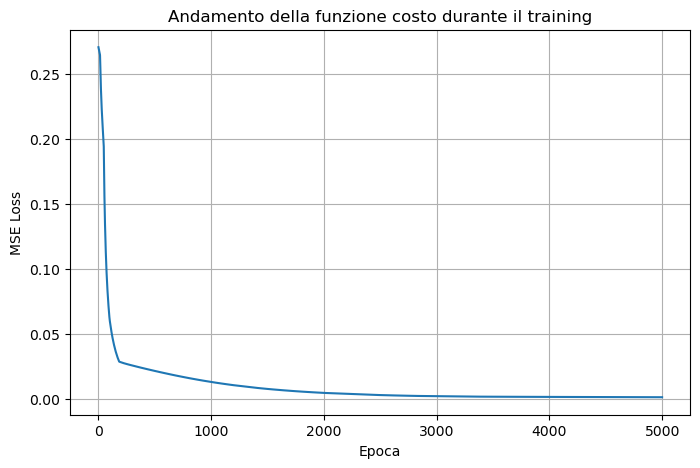

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoca")
plt.ylabel("MSE Loss")
plt.title("Andamento della funzione costo durante il training")
plt.grid(True)
plt.show()


## 8. Predizioni sui dati di training

Forward pass finale con i pesi appresi, poi denormalizzazione:

$$y = z_1^{(2)} \cdot (y_{\max} - y_{\min}) + y_{\min}$$


In [8]:
# Forward pass finale
A1_f = W1 @ Z0 + b1
Z1_f = relu(A1_f)
A2_f = W2 @ Z1_f + b2
Z2_f = relu(A2_f)   # z_1^(2) = ŷ normalizzato, shape (1, n)

# Denormalizzazione
y_pred = Z2_f * (y_max - y_min) + y_min   # shape (1, n)

for i in range(n):
    pr = y[i]
    pp = y_pred[0, i]
    print(f"Casa {i+1}: {X[i,0]:.0f} mq, {X[i,1]:.0f} stanze  |  "
          f"reale {pr:.1f} k€  |  previsto {pp:.1f} k€  |  errore {abs(pp-pr):.1f} k€")


Casa 1: 40 mq, 2 stanze  |  reale 95.0 k€  |  previsto 95.0 k€  |  errore 0.0 k€
Casa 2: 55 mq, 2 stanze  |  reale 120.0 k€  |  previsto 109.6 k€  |  errore 10.4 k€
Casa 3: 70 mq, 3 stanze  |  reale 150.0 k€  |  previsto 162.1 k€  |  errore 12.1 k€
Casa 4: 85 mq, 3 stanze  |  reale 180.0 k€  |  previsto 175.5 k€  |  errore 4.5 k€
Casa 5: 100 mq, 4 stanze  |  reale 215.0 k€  |  previsto 228.0 k€  |  errore 13.0 k€
Casa 6: 120 mq, 4 stanze  |  reale 250.0 k€  |  previsto 245.8 k€  |  errore 4.2 k€
Casa 7: 140 mq, 5 stanze  |  reale 295.0 k€  |  previsto 302.8 k€  |  errore 7.8 k€
Casa 8: 160 mq, 5 stanze  |  reale 335.0 k€  |  previsto 320.6 k€  |  errore 14.4 k€


## 9. Grafici dei risultati

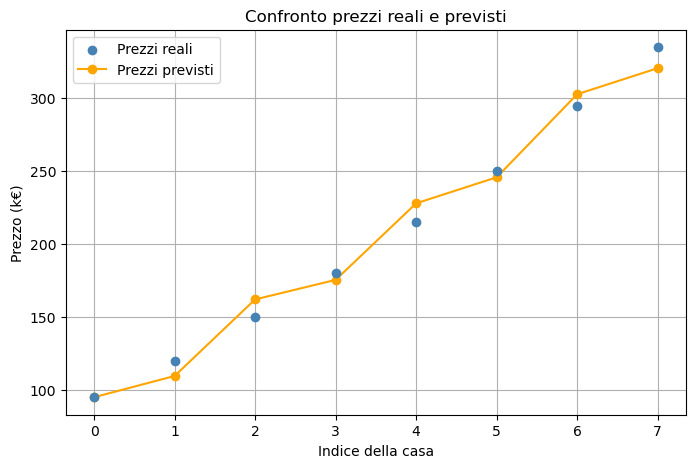

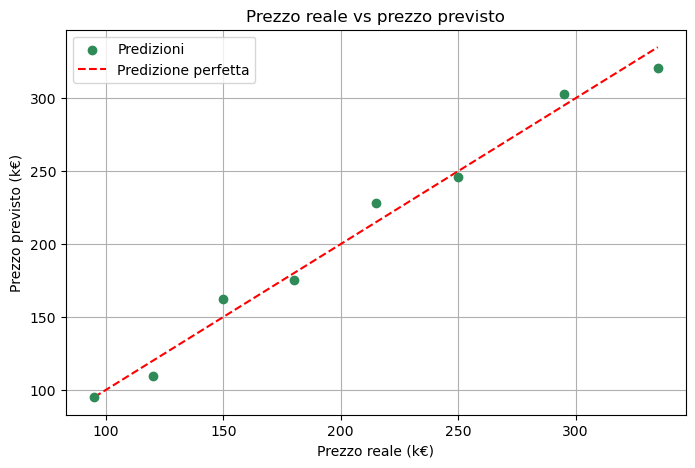

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(range(n), y, label="Prezzi reali", color="steelblue", zorder=3)
plt.plot(range(n), y_pred.flatten(), marker="o", label="Prezzi previsti", color="orange")
plt.xlabel("Indice della casa")
plt.ylabel("Prezzo (k€)")
plt.title("Confronto prezzi reali e previsti")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred.flatten(), label="Predizioni", color="seagreen", zorder=3)
plt.plot([y.min(), y.max()], [y.min(), y.max()],
         label="Predizione perfetta", color="red", linestyle="--")
plt.xlabel("Prezzo reale (k€)")
plt.ylabel("Prezzo previsto (k€)")
plt.title("Prezzo reale vs prezzo previsto")
plt.legend(); plt.grid(True); plt.show()
# Sulla diagonale tratteggiata rossa: la "predizione perfetta", cioè la diagonale dove previsto = reale.
#Se la rete fosse perfetta, ogni punto cadrebbe esattamente sulla diagonale rossa. Quanto più un punto si avvicina alla diagonale, tanto più accurata è la previsione per quella casa.

## 10. Predizione per una nuova casa (110 mq, 4 stanze)

In [15]:
nuova_casa = np.array([[110, 4]], dtype=float)
z0_new     = ((nuova_casa - X_min) / (X_max - X_min)).T   # z^(0), shape (2,1)

A1_new = W1 @ z0_new + b1
Z1_new = relu(A1_new)          # z^(1), shape (3,1)
A2_new = W2 @ Z1_new + b2
Z2_new = relu(A2_new)          # z_1^(2) = ŷ, shape (1,1)

prezzo = Z2_new * (y_max - y_min) + y_min
print(f"Prezzo stimato: {prezzo[0,0]:.2f} k€")


Prezzo stimato: 236.88 k€
